# TorchRL Chess
## What is RL?
Reinforcement Learning (RL) is a type of unsupervised machine learning. Below is a comparision between the other types of ML:
1. Supervised - all instances have labels
2. Semisupervised - some instances have labels
3. Unsupervised - instances have no labels
    - In RL, the instances come from the **environment**

The environment is defined by the user, and must include `__init__()`, `step()`, and `reset()` functions to define how it can be interacted with during training. Below is an excerpt of the `step` function used to train my RL model, modified from one provided by torchrl's `ChessEnv`. It returns information gathered by the environment, also known as an **observation**, the reward, and the state of the training run (`terminated`, `trunacated`). In torchrl, these are passed as Tensors.

In [2]:
import torch
from chess import Move

def _step(self, tensordict):      
        # action
        action = tensordict.get("action")
        board = self.board
       
        pgn = None
        fen = None
        if not self.stateful:
            if self.include_fen:
                fen = tensordict.get("fen").data
                board.set_fen(fen)
            elif self.include_pgn:
                pgn = tensordict.get("pgn").data
                board = self._pgn_to_board(pgn, board)
            else:
                raise RuntimeError(
                    "Not enough information to deduce the board. If stateful=False, include_pgn or include_fen must be True."
                )
                

        san = self.san_moves[action]
        
        REWARDS = {
            "BASE": -0.005,
            "CHECKMATE": 1,
            "LOSS": -1,
        }
        
        # Reward calculation
        reward_val = REWARDS["BASE"]
    
               
        board.push_san(san)
        
        if board.is_game_over():
            outcome = board.outcome()
            agent_won = outcome.winner is not None and outcome.winner is not board.turn
            
            if agent_won:
                reward_val += REWARDS["CHECKMATE"]
            else:
                reward_val -= REWARDS["LOSS"]
            
            self.logger.write(f"\n{self.game_count + 1},{outcome.termination.name},{agent_won}")
            self.logger.flush()
            self.game_count += 1
        else:       
            # Bot move     
            self.stockfish.set_fen_position(board.fen())
            best_move = self.stockfish.get_best_move()
            best_move = Move.from_uci(best_move)
            board.push(best_move)
        
        dest = tensordict.empty()

        # Collect data
        if self.include_fen:
            fen = board.fen()
            dest.set("fen", fen)

        if self.include_pgn:
            if pgn is not None:
                pgn = self._add_move_to_pgn(pgn, board.move_stack[-1])
            else:
                pgn = self._board_to_pgn(board)
            dest.set("pgn", pgn)

        if self.include_san:
            dest.set("san", san)

        if self.include_legal_moves:
            moves_idx = self._legal_moves_to_index(
                board=board, pad=True, return_mask=self.mask_actions
            )
            if self.mask_actions:
                moves_idx, mask = moves_idx
                dest.set("action_mask", mask)
            dest.set("legal_moves", moves_idx)
        elif self.mask_actions:
            dest.set(
                "action_mask",
                self._legal_moves_to_index(
                    board=self.board, pad=True, return_mask=True
                )[1],
            )

        turn = torch.tensor(board.turn)
        done = self._is_done(board)

        reward = torch.tensor([reward_val], dtype=torch.float32)
        dest.set("reward", reward)
        dest.set("turn", turn)
        dest.set("done", [done])
        dest.set("terminated", [done])
        if self.pixels:
            dest.set("pixels", self._get_tensor_image(board=self.board))
       
        
        return dest

## The Actor-Critic Model
The **actor** is the thing - in most cases, a neural network - that interacts with the environment. Just like in supervised learning, the actor is updated periodically via backpropogation.  

In [3]:
from torch import nn
import torch.nn.functional as F

class ChessActor(nn.Module):
    def __init__(self, n_obs, n_actions):
        super().__init__()
        self.fc1 = nn.Linear(n_obs, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, n_actions)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = x.float()
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

## The Critic in the Actor-Critic Model
Backpropogation is awesome, but if we are using unsupervised learning, how do we calculate the loss to use? That's where the `critic` and advantage come into play. Below is the `critic`, which is used to calculate the advantage and loss based by estimating the reward generated by the action chosen by the **actor**.

In [4]:
from torch import nn

class ChessCritic(nn.Module):
    def __init__(self, n_obs):
        super(ChessCritic, self).__init__()
        self.fc1 = nn.Linear(n_obs, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.float()
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        
        return x

## Advantage and Loss
Advantage is a measure of how the current action compares to its previous ones, and is used to teach the critic how to better estimate the reward for a given action. Loss is generated by our loss function for both the actor and critic, and is what enables learning via gradient descent.

Below is the intialization code for the model and its environment, with paramters ommitted for clarity. torchrl works with `tensordicts`, which are a convient way to map tensors to keys in a python dictionary. The actual environment is represented by a hashed version of the current board's FEN string.

In [5]:
from tensordict.nn import TensorDictModule
from env import ChessEnv
from torchrl.modules import ProbabilisticActor, ValueOperator, MaskedCategorical
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.ppo import GAE
from torch.optim import Adam

env = ChessEnv(include_legal_moves=True, include_hash=True, include_fen=True)
n_obs = env.observation_spec["fen_hash"].shape[0]

n_actions = env.action_spec.n

actor_net = ChessActor(n_obs, n_actions)

actor_mod = TensorDictModule(
    module=actor_net,
    in_keys=["fen_hash"],
    out_keys=["logits"],
)

actor = ProbabilisticActor(
    module=actor_mod,
    in_keys={                               
        "logits": "logits",                # map logits → logits
        "mask": "action_mask",             # map mask   → action_mask
    },
    out_keys=["action"],
    distribution_class=MaskedCategorical,   # applies the mask under the hood
    return_log_prob=True,                  # returns log_prob
)

critic_net = ChessCritic(n_obs)

critic = ValueOperator(
    module=critic_net,
    in_keys=["fen_hash"],
    out_keys=["state_value"],
)

loss_fn = ClipPPOLoss(
    actor_network=actor,
    critic_network=critic,
    entropy_bonus=True,
    normalize_advantage=True,
)

advantage = GAE(
    value_network=critic,
    gamma=0.99,
    lmbda=0.95,
)

optimizer = Adam(
    loss_fn.parameters(),
)

/home/bryan/github/cpp/torchrl-chess/.venv/lib/python3.12/site-packages/torchrl/data/replay_buffers/samplers.py:37: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


## Training
Training is conducted using the `SyncDataCollector` util provided by torchrl. Each batch or **episode** executes a certain number of steps, collects the results, the computes the advantage and loss before updating the actor and critic network gradients.

In [6]:
from torchrl.collectors import SyncDataCollector

def fit(episodes, max_steps_per_episode, epochs_per_episode):
    collector = SyncDataCollector(
        env,
        actor,
        total_frames=episodes * max_steps_per_episode,
        frames_per_batch=max_steps_per_episode,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, episodes, 0.0
    )

    for episode, data in enumerate(collector):
        for epoch in range(epochs_per_episode):
            advantage(data)
                    
            total_loss = 0
            loss = loss_fn(data)
            for k, v in loss.items():
                if "loss" in k:
                    total_loss += v
         
            total_loss.backward()
            
            optimizer.step()
            optimizer.zero_grad() 
        scheduler.step()

# Let's Play
This model is trained on 1,000 games against itself using a GCP v4 TPU, which took around 20 minutes.

In [14]:
from IPython.display import display, clear_output
import torch
import numpy as np
import torch
from model import Model

model = Model()
model.load("./runs/latest/model.pth", device=torch.device("cpu"))

env = model.env
actor = model.actor

observation shape: 32, action space: 29275
Model loaded from ./runs/latest/model.pth


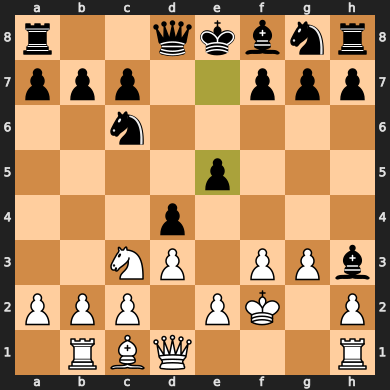

KeyboardInterrupt: 

In [15]:
import time
from chess import Move
obs = env.reset()
interactive = False
fps = 4

while not env.board.is_game_over():
    clear_output(wait=True)
    display(env.board)
    legal_moves = env.get_legal_moves(uci=True)
    player_move = ""
    while interactive and player_move not in legal_moves and player_move != "exit":
        player_move = input("Enter your uci move:")
        
    if player_move == "exit":
        break
    elif not player_move:
        player_move = np.random.choice(legal_moves)
        time.sleep(1 / fps)
    
    player_move = Move.from_uci(player_move)
    player_move = env.board.san(player_move)

    obs = actor(obs)
    obs['action'] = torch.tensor([env.san_moves.index(player_move)])
    obs = env.step(obs)

## Considerations
### Interesting Trends
- The best model was only given rewards for winning or losing
    - Other rewards/penalties resulted in the actor choosing to extend games rather than pursue checkmate
    - Rewards are not linearly independent, making the reward function more like a \* b \* c rather than mx + b
- Its very difficult for the model to make purely "strategic" moves like castling

### Improvements
Potential areas for improvement:
- use a CNN for the input layer of both models
    - either 1d CNN or convert board FEN to 8x8 tensor
- use a shared layer for both models
- experiment with the reward scaling
    - right now, there is an even reward for winning and losing

## Try it out yourself
Feel free to play with the model here: [Demo](https://github.com/blbergo/torchrl-chess/blob/fdb67694309196ec44c05acddf450df8a306f924/src/demo.ipynb)